# Tema 4: VLM Architecture

Before diving in, let's import what we need

In [1]:
import torch
import torch.nn.functional as F

import numpy as np
import itertools
from PIL import Image

from transformers import ViTImageProcessor, ViTModel
from transformers import AutoProcessor, AutoModelForMultimodalLM

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')

Device: cuda


In [2]:
image1 = Image.open("./wolf1.jpg").convert("RGB")
image2 = Image.open("./wolf2.jpg").convert("RGB")
image3 = Image.open("./wolf3.jpg").convert("RGB")
image4 = Image.open("./wolf4.jpg").convert("RGB")

images = [image1,image2,image3,image4]
image_len = len(images)

Images Dimensions ->   Image 1: (474, 313)   |   Image 2: (516, 344)   |   Image 3: (600, 322)   |   Image 4: (516, 344)



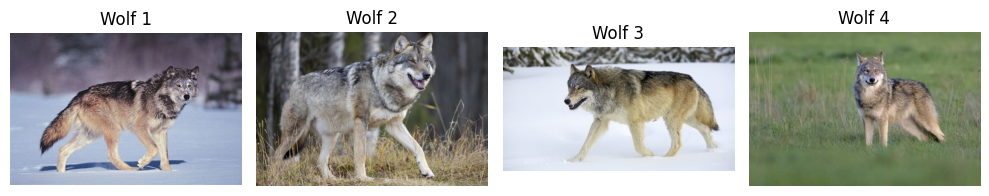

In [26]:
text_dim = "Images Dimensions -> "

fig, axes = plt.subplots(1,image_len, figsize=(10, 10))

for i, image in enumerate(images):
    text_dim += f"  Image {i+1}: {image.size}{'\n' if i == image_len - 1 else '   | '}"

    axes[i].imshow(image)
    axes[i].set_title(f"Wolf {i+1}")
    axes[i].axis("off")

plt.tight_layout()

print(text_dim)
plt.show()

---

---

## 4A: Visualize Patch Embeddings
Here's our goal:
> Pass 2 similar images through a CLIP / ViT model.
>
> Extract patch embeddings and project them (PCA / t-SNE).
>
> Compare how object patches cluster vs background.

In [28]:
# Model
model_name = "google/vit-base-patch16-224-in21k"

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTModel.from_pretrained(model_name).to(device)

model.eval()

print(f"\nModel: {model_name}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Model: google/vit-base-patch16-224-in21k


In [29]:
all_patches = []

for i, image in enumerate(images):
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    embeddings = outputs.last_hidden_state[0]
    patches = embeddings[1:]
    all_patches.append(patches)
    print(f"Image {i+1}: Inputs shape {inputs['pixel_values'].shape} -- Embeddings shape {embeddings.shape} -- Patches shape {patches.shape}")


all_patches = torch.cat(all_patches, dim=0)
X = all_patches.cpu().numpy()
print("\nCombined:", X.shape)

Image 1: Inputs shape torch.Size([1, 3, 224, 224]) -- Embeddings shape torch.Size([197, 768]) -- Patches shape torch.Size([196, 768])
Image 2: Inputs shape torch.Size([1, 3, 224, 224]) -- Embeddings shape torch.Size([197, 768]) -- Patches shape torch.Size([196, 768])
Image 3: Inputs shape torch.Size([1, 3, 224, 224]) -- Embeddings shape torch.Size([197, 768]) -- Patches shape torch.Size([196, 768])
Image 4: Inputs shape torch.Size([1, 3, 224, 224]) -- Embeddings shape torch.Size([197, 768]) -- Patches shape torch.Size([196, 768])

Combined: (784, 768)


PCA result: (784, 2)
Explained variance: [0.21522284 0.15010111]


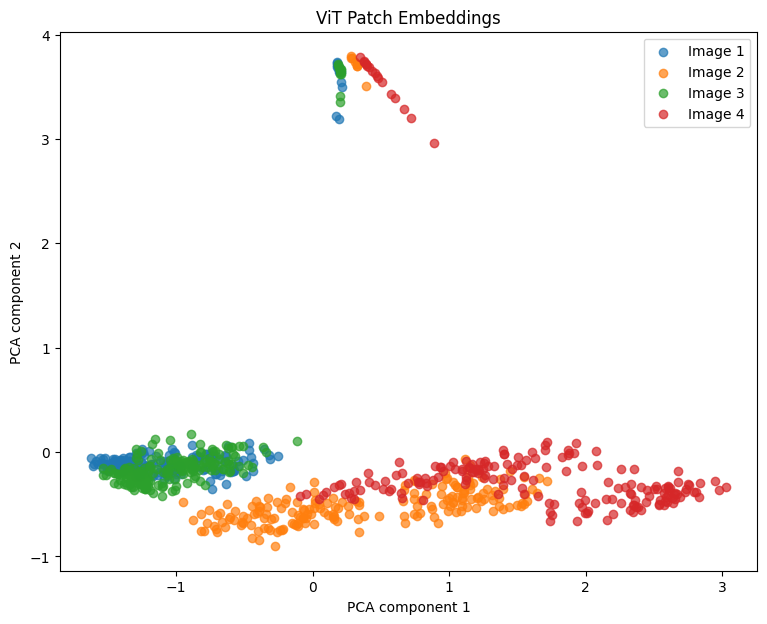

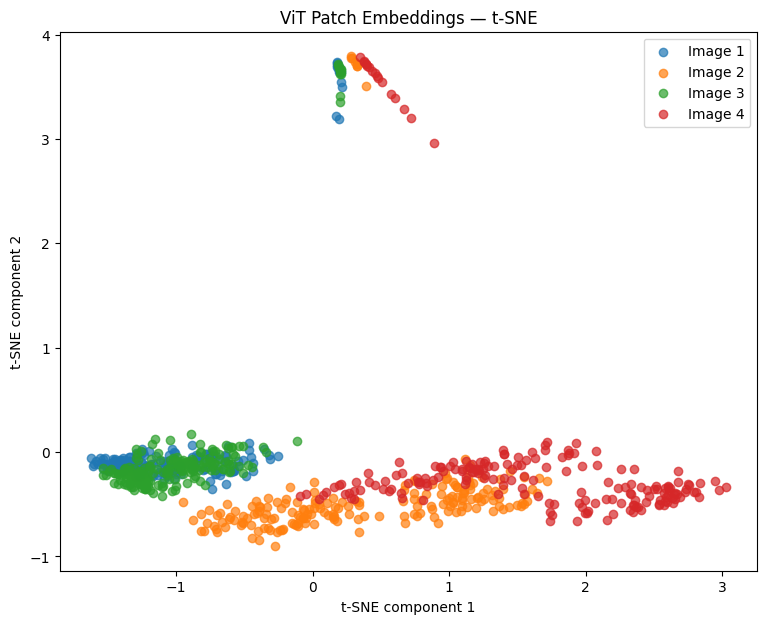

In [30]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("PCA result:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_)
plt.figure(figsize=(9, 7))

for i in range(image_len):
  plt.scatter(
      X_pca[i*196:(i+1)*196, 0],
      X_pca[i*196:(i+1)*196, 1],
      label=f"Image {i+1}",
      alpha=0.7
  )

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("ViT Patch Embeddings")
plt.legend()
plt.show()


# Apply t-SNE to the patch embeddings
X_tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
).fit_transform(X)

plt.figure(figsize=(9, 7))

for i in range(image_len):
  plt.scatter(
      X_pca[i*196:(i+1)*196, 0],
      X_pca[i*196:(i+1)*196, 1],
      label=f"Image {i+1}",
      alpha=0.7
  )

plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.title("ViT Patch Embeddings — t-SNE")
plt.legend()
plt.show()



PCA explained variance: [0.21522291 0.15010104]


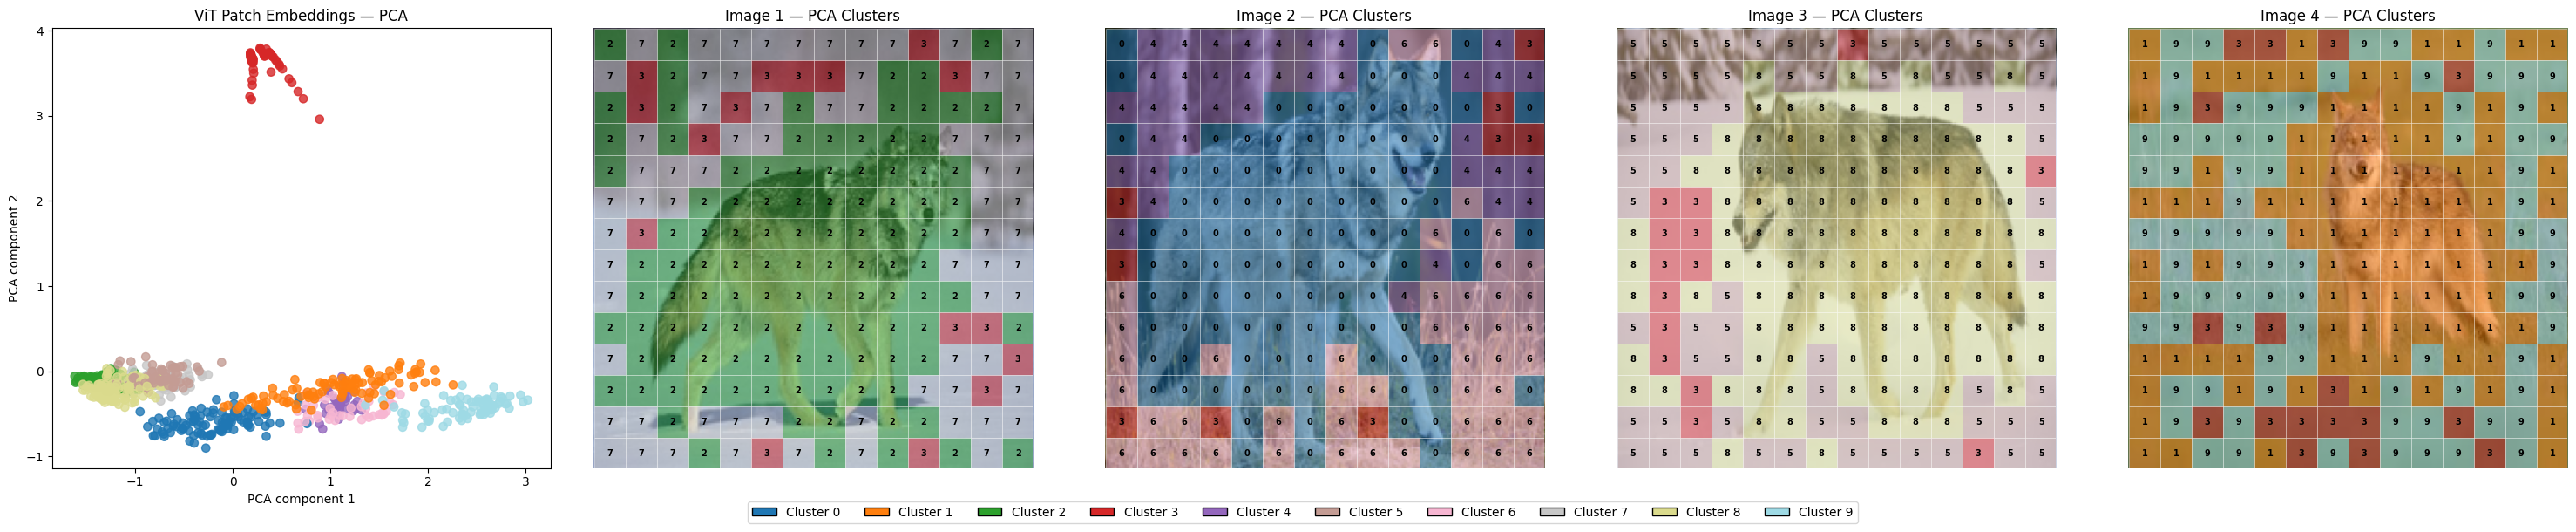

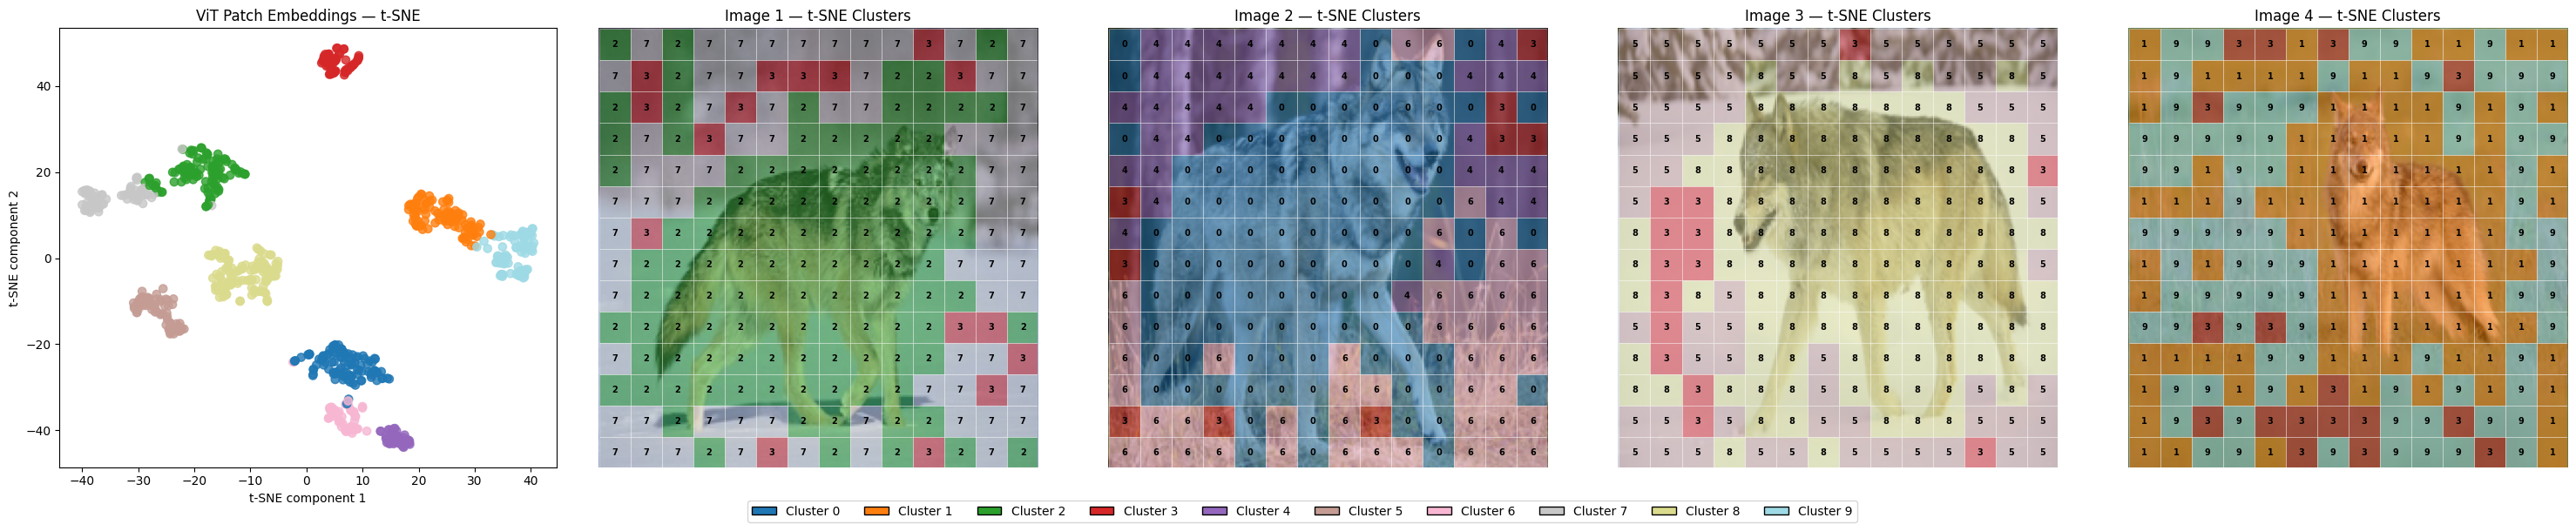

In [31]:
N_CLUSTERS = 10
N_PATCHES = 196
GRID_SIZE = 14
IMAGE_SIZE = 224


# Cluster the original ViT patch embeddings
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)


# Organize cluster labels into one grid per image
labels = [
    cluster_labels[i * N_PATCHES:(i + 1) * N_PATCHES].reshape(GRID_SIZE, GRID_SIZE)
    for i in range(image_len)
]


# Cluster colors
colors = plt.cm.tab20(np.linspace(0, 1, N_CLUSTERS))
cmap = ListedColormap(colors)


def draw_clustered_image(ax, image, labels, title):
    image = image.resize((IMAGE_SIZE, IMAGE_SIZE))
    ax.imshow(image)

    patch_size = IMAGE_SIZE // GRID_SIZE

    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            cluster = labels[row, col]

            ax.add_patch(
                plt.Rectangle(
                    (col * patch_size, row * patch_size),
                    patch_size,
                    patch_size,
                    facecolor=colors[cluster],
                    edgecolor="white",
                    linewidth=0.5,
                    alpha=0.5
                )
            )

            ax.text(
                col * patch_size + patch_size / 2,
                row * patch_size + patch_size / 2,
                str(cluster),
                ha="center",
                va="center",
                fontsize=7,
                color="black",
                fontweight="bold"
            )

    ax.set_title(title)
    ax.axis("off")


def plot_embedding(reduced_X, method):
    fig, axes = plt.subplots(
        1,
        image_len + 1,
        figsize=(6 * (image_len + 1), 6)
    )

    # Embedding visualization
    axes[0].scatter(
        reduced_X[:, 0],
        reduced_X[:, 1],
        c=cluster_labels,
        cmap=cmap,
        s=45,
        alpha=0.8
    )

    axes[0].set_title(f"ViT Patch Embeddings — {method}")
    axes[0].set_xlabel(f"{method} component 1")
    axes[0].set_ylabel(f"{method} component 2")

    # Image visualizations
    for i, (image, image_labels) in enumerate(zip(images, labels)):
        draw_clustered_image(
            axes[i + 1],
            image,
            image_labels,
            f"Image {i + 1} — {method} Clusters"
        )

    # Legend
    fig.legend(
        handles=[
            Patch(
                facecolor=colors[i],
                edgecolor="black",
                label=f"Cluster {i}"
            )
            for i in range(N_CLUSTERS)
        ],
        loc="lower center",
        ncol=N_CLUSTERS,
        bbox_to_anchor=(0.5, -0.02)
    )

    plt.tight_layout()
    plt.show()


# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("PCA explained variance:", pca.explained_variance_ratio_)
plot_embedding(X_pca, "PCA")


# t-SNE
X_tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
).fit_transform(X)

plot_embedding(X_tsne, "t-SNE")


---

## 4B: Compare Model Behavior
Here's the task:
> Feed both images + the same prompt into a VLM.
>
> Compare:
> - Caption or answer differences
> - Embedding similarity
> - How small changes (angle, lighting) affect output


In [3]:
model_name = "HuggingFaceTB/SmolVLM-500M-Instruct"

processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForMultimodalLM.from_pretrained(model_name).to(device)

model.eval()

print(f"\nModel: {model_name}")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]


Model: HuggingFaceTB/SmolVLM-500M-Instruct


In [4]:
prompt_text = (
    "Describe the image in 2–3 simple sentences. Mention the main subject, what it is doing, and the most noticeable details about its appearance and surroundings."
)


captions = []
image_embeddings = []

for i, image in enumerate(images, start=1):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt_text}
            ]
        }
    ]
    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True
    )

    inputs = processor(
        text=prompt,
        images=[image],
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        hidden_outputs = model(**inputs, output_hidden_states=True)

    last_hidden = hidden_outputs.hidden_states[-1][0]
    image_embedding = last_hidden.mean(dim=0)
    image_embeddings.append(image_embedding.cpu())

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=1000,
            do_sample=False
        )

    input_length = inputs["input_ids"].shape[1]
    generated_text = generated_ids[:, input_length:]

    answer = processor.batch_decode(
        generated_text,
        skip_special_tokens=True
    )[0].strip()

    answer = answer.replace("\n\n", "\n")
    captions.append(answer)

    print(f"--- Image {i} ---")
    print(answer + "\n\n")

image_embeddings = torch.stack(image_embeddings)
print("Image embeddings shape:", image_embeddings.shape)


--- Image 1 ---
In the image, there is a wolf walking on a snow-covered ground. The wolf is in mid-stride, with its head turned slightly to the right. The fur on its body is a mix of brown and gray, with some lighter patches. The background is a snowy landscape with a few trees in the distance.


--- Image 2 ---
In the image, there is a wolf walking on the ground. The wolf is gray and brown in color, with a black nose and yellow eyes. The background is blurred, but it looks like there are trees behind the wolf.


--- Image 3 ---
In the image, there is a wolf walking on the snow. The background is a snowy landscape with some trees covered in snow.


--- Image 4 ---
In the image, there is a dog standing on a grassy field. The dog is in the center of the image and is looking straight ahead. The background is blurred, and the dog is in focus. The dog has a light brown and white coat with some darker patches on its face and back. The grass is green and appears to be well-maintained.


Image

In [5]:
def embed_text_with_model(text):
    input_ids = processor.tokenizer(text, return_tensors="pt")["input_ids"].to(device)
    with torch.no_grad():
        token_embeds = model.get_input_embeddings()(input_ids)[0]  # (seq_len, hidden_dim)
    return token_embeds.mean(dim=0).cpu()

def cosine_similarity_matrix(embeddings):
    embeddings = embeddings.float()  # BF16 -> FP32
    normed = F.normalize(embeddings, dim=1)
    return (normed @ normed.T).numpy()


def plot_similarity_matrix(sim, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(sim, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(image_len))
    ax.set_yticks(range(image_len))
    ax.set_xticklabels([f"Image {i+1}" for i in range(image_len)])
    ax.set_yticklabels([f"Image {i+1}" for i in range(image_len)])
    for i in range(image_len):
        for j in range(image_len):
            ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center",
                    color="white" if sim[i, j] < 0.75 else "black")
    ax.set_title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

Caption embeddings shape: torch.Size([4, 960])
SmolVLM image-embedding cosine similarity:



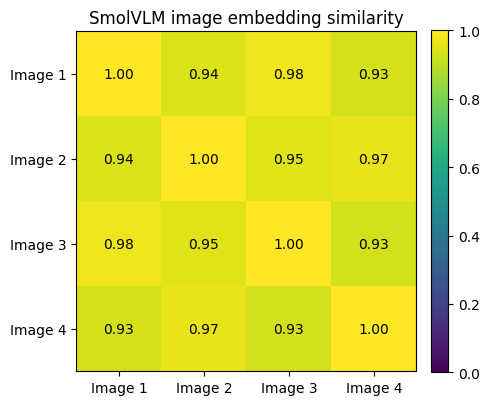

In [22]:
caption_embeddings = torch.stack([embed_text_with_model(c) for c in captions])
print("Caption embeddings shape:", caption_embeddings.shape)

image_sim = cosine_similarity_matrix(image_embeddings)
print("SmolVLM image-embedding cosine similarity:\n")
plot_similarity_matrix(image_sim, "SmolVLM image embedding similarity")


SmolVLM caption-embedding cosine similarity:



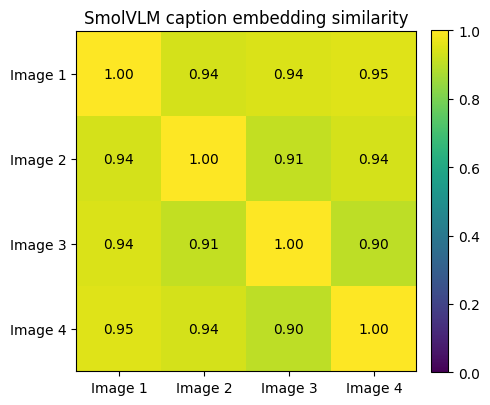

In [23]:
caption_sim = cosine_similarity_matrix(caption_embeddings)
print("SmolVLM caption-embedding cosine similarity:\n")
plot_similarity_matrix(caption_sim, "SmolVLM caption embedding similarity")


In [24]:
print(f"{'Pair':<10}{'Image sim':<14}{'Caption sim':<14}{'Gap':<10}")
for i, j in itertools.combinations(range(image_len), 2):
    v, c = image_sim[i, j], caption_sim[i, j]
    print(f"{f'Img{i+1}-Img{j+1}':<10}{v:<14.3f}{c:<14.3f}{abs(v - c):<10.3f}")


Pair      Image sim     Caption sim   Gap       
Img1-Img2 0.942         0.937         0.005     
Img1-Img3 0.975         0.944         0.032     
Img1-Img4 0.934         0.950         0.016     
Img2-Img3 0.952         0.909         0.044     
Img2-Img4 0.967         0.937         0.030     
Img3-Img4 0.930         0.902         0.029     
